In [13]:
# import OS and check if dataset is mounted
import os

print("Datasets mounted at /kaggle/input:")
print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/datasets")[:50])
print(os.listdir("/kaggle/input/datasets/organizations")[:100])

Datasets mounted at /kaggle/input:
['datasets']
['organizations']
['nih-chest-xrays']


In [14]:
# Storing root path of ChestXray14 dataset
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays"
print(os.listdir(DATA_ROOT)[:200])

['data']


In [15]:
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

first_png = None
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith(".png"):
            first_png = os.path.join(root, f)
            break
    if first_png:
        break

print("First PNG found:", first_png)


First PNG found: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png


In [16]:
# Importing PIL to open images and tqdm for progress bars as well as random for reproducibilty
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

# PyTorch and its neural network tools.
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# auroc metric from sklearn
from sklearn.metrics import roc_auc_score



In [17]:
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = DATA_ROOT + "/Data_Entry_2017.csv"

LABELS = [
    "Atelectasis","Cardiomegaly","Effusion","Infiltration","Mass","Nodule",
    "Pneumonia","Pneumothorax","Consolidation","Edema","Emphysema","Fibrosis",
    "Pleural_Thickening","Hernia"
]
label2idx = {l:i for i,l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [18]:
# Pointing to the metadata csv that contains image names, patient IDs, and label
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = DATA_ROOT + "/Data_Entry_2017.csv"

# The 14 chest disease classes
LABELS = [
    "Atelectasis","Cardiomegaly","Effusion","Infiltration","Mass","Nodule",
    "Pneumonia","Pneumothorax","Consolidation","Edema","Emphysema","Fibrosis",
    "Pleural_Thickening","Hernia"
]

# Creating a dictionary for these labels
label2idx = {l:i for i,l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

# use a same seed to reproduce results
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


In [19]:
# collect all subdirectories inside DATA_ROOT that match 'images_' and contain an 'images' folder
img_dirs = [
    os.path.join(DATA_ROOT, d, "images")
    for d in os.listdir(DATA_ROOT)
    if d.startswith("images_") and os.path.isdir(os.path.join(DATA_ROOT, d, "images"))
]

# print number of image directories found and preview a few paths
print("Image folders found:", len(img_dirs))
print("Example dirs:", img_dirs[:3])

# create a dictionary mapping image filenames to their full file paths
name2path = {}
for d in img_dirs:
    for f in os.listdir(d):
        if f.endswith(".png"):
            name2path[f] = os.path.join(d, f)

# print total number of indexed images and check if a sample file exists
print("Indexed images:", len(name2path))
print("Has 00000001_000.png?", "00000001_000.png" in name2path)

Image folders found: 12
Example dirs: ['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images']
Indexed images: 112120
Has 00000001_000.png? True


In [20]:
# load dataset from CSV file into a DataFrame
df = pd.read_csv(CSV_PATH)

# get unique patient IDs and shuffle them for random splitting
patients = df["Patient ID"].unique()
np.random.shuffle(patients)

# split sizes (80% train, 10% validation, 10% test)
n = len(patients)
train_ids = set(patients[: int(0.8*n)])
val_ids   = set(patients[int(0.8*n): int(0.9*n)])
test_ids  = set(patients[int(0.9*n):])

# split the DataFrame based on patient IDs to avoid data leakage
train_df = df[df["Patient ID"].isin(train_ids)].copy()
val_df   = df[df["Patient ID"].isin(val_ids)].copy()
test_df  = df[df["Patient ID"].isin(test_ids)].copy()

# print number of samples in each split
print(len(train_df), len(val_df), len(test_df))

89703 11221 11196


In [21]:
class ChestXray14(Dataset):
    # store dataframe and reset index for consistent access
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    # return total number of samples
    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        # get row corresponding to index i
        row = self.df.iloc[i]
        fname = row["Image Index"]
        
        # load image in grayscale and convert to 3-channel RGB
        img_path = name2path[fname]
        img = Image.open(img_path).convert("L")

        # initialize multi-label target vector
        y = np.zeros(NUM_LABELS, dtype=np.float32)
        
         # set labels to 1 for each disease present
        for f in str(row["Finding Labels"]).split("|"):
            if f in label2idx:
                y[label2idx[f]] = 1.0

        # apply data transformations if provided
        if self.transform:
            img = self.transform(img)

        # return image tensor and corresponding label tensor
        return img, torch.tensor(y)


# define target image size
IMG_SIZE = 224

# training transformations (resize and convert to tensor)
train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# validation transformations (same preprocessing as training)
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# test transformations (same preprocessing for consistent evaluation)
test_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [22]:
# define batch size and number of workers for data loading
BATCH_SIZE = 32
NUM_WORKERS = 0

# create DataLoader for training set (shuffle enabled for randomness)
train_loader = DataLoader(ChestXray14(train_df, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)

# create DataLoader for validation set (no shuffling for consistent evaluation)
val_loader = DataLoader(ChestXray14(val_df, val_tf),
                        batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# create DataLoader for test set (no shuffling, same preprocessing as validation)
test_loader = DataLoader(ChestXray14(test_df, val_tf),
                         batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

In [23]:
from sklearn.linear_model import RidgeClassifier
from sklearn.multiclass import OneVsRestClassifier

# convert DataLoader batches into NumPy arrays
def loader_to_numpy(loader):
    X_list = []
    y_list = []

    # iterate over batches from DataLoader
    for x, y in tqdm(loader):
        # flatten images into feature vectors and convert to NumPy (float16 to reduce memory)
        x = x.view(x.size(0), -1).cpu().numpy().astype(np.float16)
        # convert labels to NumPy arrays
        y = y.cpu().numpy().astype(np.float32)
        
        # store batch features and labels
        X_list.append(x)
        y_list.append(y)
    # concatenate all batches into full dataset arrays
    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(y_list, axis=0)
    
    # return feature matrix and label matrix
    return X, Y

In [24]:
# Convert existing loaders to numpy arrays
X_train, y_train = loader_to_numpy(train_loader)
X_val, y_val = loader_to_numpy(val_loader)
X_test, y_test = loader_to_numpy(test_loader)

100%|██████████| 350/350 [05:10<00:00,  1.13it/s]


In [25]:
# Train Ridge Classifier
ridge = OneVsRestClassifier(RidgeClassifier(class_weight="balanced"))
ridge.fit(X_train, y_train)


OneVsRestClassifier(estimator=RidgeClassifier(class_weight='balanced'))

In [26]:
# compute raw decision scores for the validation set
y_val_scores = ridge.decision_function(X_val)

# compute raw decision scores for the test set
y_test_scores = ridge.decision_function(X_test)

In [27]:
# compute AUROC for each class individually (validation set)
val_auc_per_class = roc_auc_score(y_val, y_val_scores, average=None)

# compute overall mean AUROC across all classes (validation set)
val_mean_auc = roc_auc_score(y_val, y_val_scores, average="macro")


In [28]:
# compute AUROC for each class individually (test set)
test_auc_per_class = roc_auc_score(y_test, y_test_scores, average=None)

# compute overall mean AUROC across all classes (test average)
test_mean_auc = roc_auc_score(y_test, y_test_scores, average="macro")



In [29]:
# print overall validation performance (mean AUROC across all classes)
print("Validation Mean AUROC:", val_mean_auc)

# print AUROC score for each class on the validation set
for name, auc in zip(LABELS, val_auc_per_class):
    print(f"VAL  {name:18s}: {auc:.4f}")


Validation Mean AUROC: 0.6009853140412142
VAL  Atelectasis       : 0.5943
VAL  Cardiomegaly      : 0.6292
VAL  Effusion          : 0.6744
VAL  Infiltration      : 0.5799
VAL  Mass              : 0.5536
VAL  Nodule            : 0.5273
VAL  Pneumonia         : 0.5514
VAL  Pneumothorax      : 0.6036
VAL  Consolidation     : 0.6101
VAL  Edema             : 0.6612
VAL  Emphysema         : 0.5480
VAL  Fibrosis          : 0.5500
VAL  Pleural_Thickening: 0.5662
VAL  Hernia            : 0.7644


In [30]:
# print overall test performance (mean AUROC across all classes)
print("\nTest Mean AUROC:", test_mean_auc)

# print AUROC score for each class individually
for name, auc in zip(LABELS, test_auc_per_class):
    print(f"TEST {name:18s}: {auc:.4f}")


Test Mean AUROC: 0.5829359538937784
TEST Atelectasis       : 0.6221
TEST Cardiomegaly      : 0.6158
TEST Effusion          : 0.6748
TEST Infiltration      : 0.5948
TEST Mass              : 0.5476
TEST Nodule            : 0.5186
TEST Pneumonia         : 0.5578
TEST Pneumothorax      : 0.5736
TEST Consolidation     : 0.6055
TEST Edema             : 0.6791
TEST Emphysema         : 0.5247
TEST Fibrosis          : 0.5673
TEST Pleural_Thickening: 0.5167
TEST Hernia            : 0.5629


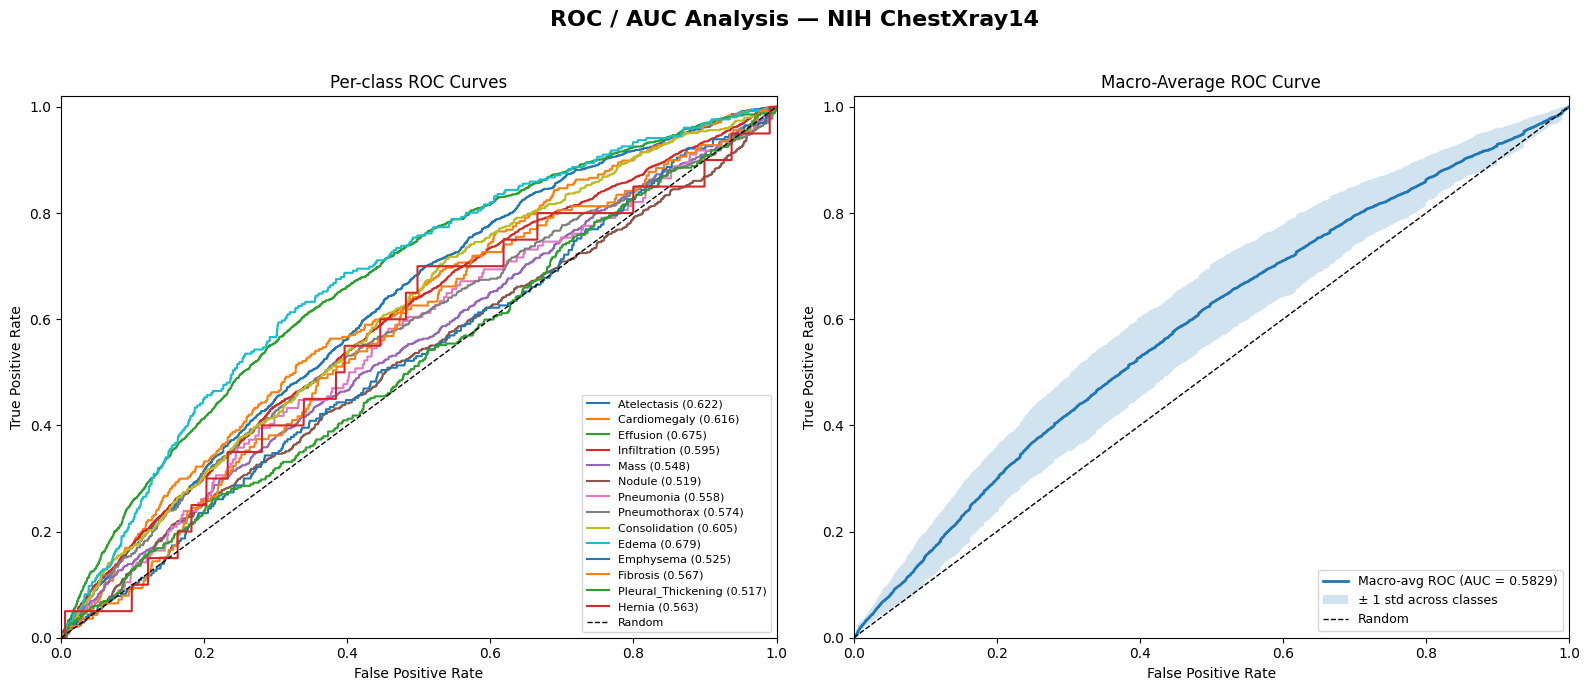

In [31]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

n_classes = len(LABELS)

# Per-class ROC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_test_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# Std band across classes
tpr_interp_all = []
for i in range(n_classes):
    tpr_interp_all.append(np.interp(all_fpr, fpr[i], tpr[i]))

tpr_interp_all = np.array(tpr_interp_all)
std_tpr = np.std(tpr_interp_all, axis=0)

tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: per-class ROC curves
for i in range(n_classes):
    axes[0].plot(fpr[i], tpr[i], lw=1.5, label=f"{LABELS[i]} ({roc_auc[i]:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label="Random")
axes[0].set_title("Per-class ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].legend(loc="lower right", fontsize=8)

# Right: macro-average ROC
axes[1].plot(all_fpr, mean_tpr, lw=2, label=f"Macro-avg ROC (AUC = {macro_auc:.4f})")
axes[1].fill_between(all_fpr, tpr_lower, tpr_upper, alpha=0.2, label="± 1 std across classes")
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label="Random")
axes[1].set_title("Macro-Average ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].legend(loc="lower right", fontsize=9)

plt.suptitle("ROC / AUC Analysis — NIH ChestXray14", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()